### **Laboratorio 5**


### **Parte 1: Análisis de paquetes**

In [27]:
from scapy.all import sniff

packets = sniff(count=10)

for i, pkt in enumerate(packets):
    print(f"\nPaquete {i+1}")
    print(f"Tipo: {type(pkt)}")
    print(f"Longitud: {len(pkt)} bytes")
    print("Contenido:")
    pkt.show()


Paquete 1
Tipo: <class 'scapy.layers.l2.Ether'>
Longitud: 179 bytes
Contenido:
###[ Ethernet ]###
  dst       = ff:ff:ff:ff:ff:ff
  src       = c0:25:67:d8:68:a0
  type      = IPv4
###[ IP ]###
     version   = 4
     ihl       = 5
     tos       = 0x0
     len       = 165
     id        = 50130
     flags     = 
     frag      = 0
     ttl       = 64
     proto     = udp
     chksum    = 0xb676
     src       = 0.0.0.0
     dst       = 255.255.255.255
     \options   \
###[ UDP ]###
        sport     = 11113
        dport     = 11111
        len       = 145
        chksum    = 0x757
###[ Raw ]###
           load      = b'\xf1\xf2\xf3\xf4i\xbaX\t\xfd}\x88j\x01\x06Vektor\x02\rAEFME904U1-v1\x03\x01\x01\n\x06\xc0%g\xd8h\xa0\x04\x04\x01\x05\xa8\xc0\x05\x01\x00\x06\x01\x01\x07\x01\x01\x08\x04\xf5\xd1\x01\x00\t\x04D\x17\xe4i\r\x12904U12021042907686\x0b\x0bSol network\x0c\x100210429181714641\x0e\x01\x02\x10\x08\x80\x95+\x94\x90\x01\x00\x00'


Paquete 2
Tipo: <class 'scapy.layers.l2.Ether'>
L

In [28]:
from scapy.layers.inet import IP, TCP, UDP

for i, pkt in enumerate(packets):
    print(f"\nPaquete {i+1}")
    
    if IP in pkt:
        src_ip = pkt[IP].src
        dst_ip = pkt[IP].dst
    else:
        src_ip = dst_ip = "N/A"
    
    if TCP in pkt:
        src_port = pkt[TCP].sport
        dst_port = pkt[TCP].dport
    elif UDP in pkt:
        src_port = pkt[UDP].sport
        dst_port = pkt[UDP].dport
    else:
        src_port = dst_port = "N/A"
    
    print(f"Src Address: {src_ip}")
    print(f"Dst Address: {dst_ip}")
    print(f"Src Port: {src_port}")
    print(f"Dst Port: {dst_port}")


Paquete 1
Src Address: 0.0.0.0
Dst Address: 255.255.255.255
Src Port: 11113
Dst Port: 11111

Paquete 2
Src Address: 192.168.5.52
Dst Address: 172.64.148.235
Src Port: 58505
Dst Port: 443

Paquete 3
Src Address: 192.168.5.52
Dst Address: 142.251.153.119
Src Port: 59137
Dst Port: 443

Paquete 4
Src Address: 192.168.5.52
Dst Address: 172.64.155.209
Src Port: 57582
Dst Port: 443

Paquete 5
Src Address: 192.168.5.52
Dst Address: 172.64.155.209
Src Port: 57582
Dst Port: 443

Paquete 6
Src Address: 192.168.5.52
Dst Address: 172.64.155.209
Src Port: 57582
Dst Port: 443

Paquete 7
Src Address: 192.168.5.52
Dst Address: 172.64.155.209
Src Port: 57582
Dst Port: 443

Paquete 8
Src Address: 192.168.5.52
Dst Address: 172.64.155.209
Src Port: 57582
Dst Port: 443

Paquete 9
Src Address: 192.168.5.52
Dst Address: 172.64.155.209
Src Port: 57582
Dst Port: 443

Paquete 10
Src Address: 192.168.5.52
Dst Address: 172.64.155.209
Src Port: 57582
Dst Port: 443


#### Estadísticas y detección con Z-Score

In [29]:
from scapy.all import rdpcap
import pandas as pd

packets = rdpcap("analisis_paquetes.pcap")

In [30]:
from scapy.layers.inet import IP, TCP, UDP
import pandas as pd

data = []

for pkt in packets:
    if IP in pkt:
        row = {
            "src_ip": pkt[IP].src,
            "dst_ip": pkt[IP].dst,
            "src_port": None,
            "dst_port": None,
            "payload_size": len(pkt.payload),
            "pkt_len": len(pkt)   # <-- CLAVE
        }

        if TCP in pkt:
            row["src_port"] = pkt[TCP].sport
            row["dst_port"] = pkt[TCP].dport
        elif UDP in pkt:
            row["src_port"] = pkt[UDP].sport
            row["dst_port"] = pkt[UDP].dport

        data.append(row)

df = pd.DataFrame(data)

In [31]:
df[["payload_size", "pkt_len"]].head()

,payload_size,pkt_len
0,961,975
1,84,98
2,975,989
3,84,98
4,1012,1026


##### **Estadisticas Basicas**

In [32]:
ip_origen_top = df["src_ip"].value_counts().idxmax()
print(ip_origen_top)

10.1.10.53


In [33]:
ip_destino_top = df["dst_ip"].value_counts().idxmax()
print(ip_destino_top)

10.1.10.53


In [34]:
df[df["src_ip"] == ip_origen_top]["dst_ip"].value_counts()

dst_ip
84.54.22.33    29
75.75.75.75     2
Name: count, dtype: int64

In [35]:
df[df["src_ip"] == ip_origen_top]["dst_port"].value_counts()

dst_port
53    31
Name: count, dtype: int64

In [36]:
df[df["dst_ip"] == ip_destino_top]["src_port"].value_counts()

src_port
53    31
Name: count, dtype: int64

In [37]:
top_ports_d = df[df["src_ip"] == ip_origen_top]["dst_port"].value_counts().head()
top_ports_e = df[df["dst_ip"] == ip_destino_top]["src_port"].value_counts().head()

print(top_ports_d)
print(top_ports_e)

dst_port
53    31
Name: count, dtype: int64
src_port
53    31
Name: count, dtype: int64


#### **Z-score sobre el tamaño del payload**

In [38]:
from scipy.stats import zscore

# Calcular Z-score basado en los datos
df["z_payload"] = zscore(df["payload_size"])

# Conteo de anomalías
outliers_2 = df[abs(df["z_payload"]) > 2]
outliers_3 = df[abs(df["z_payload"]) > 3]

print("Paquetes con |Z| > 2:", len(outliers_2))
print("Paquetes con |Z| > 3:", len(outliers_3))

outliers_3.head()

Paquetes con |Z| > 2: 0
Paquetes con |Z| > 3: 0


,src_ip,dst_ip,src_port,dst_port,payload_size,pkt_len,z_payload


No se detectaron anomalías usando Z-score clásico.
Esto ocurre porque el cálculo usa la media y desviación del mismo dataset, que está claramente sesgado.

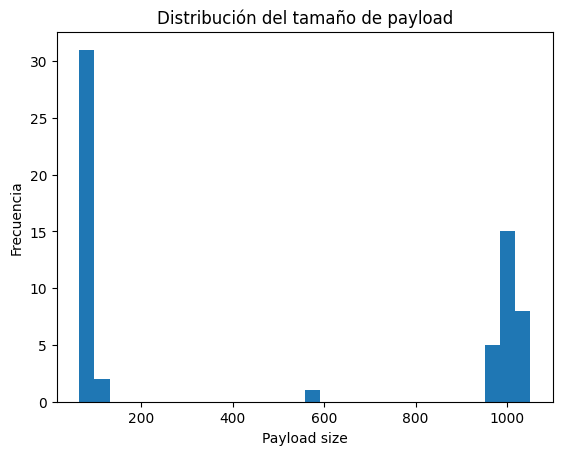

In [39]:
import matplotlib.pyplot as plt

plt.hist(df["payload_size"], bins=30)
plt.title("Distribución del tamaño de payload")
plt.xlabel("Payload size")
plt.ylabel("Frecuencia")
plt.show()

La distribución no es normal, sino bimodal, lo cual indica la presencia de distintos tipos de tráfico. Debido a esto, el Z-score no detecta anomalías correctamente, ya que asume una distribución normal unimodal.

In [40]:
mean_dns = 50
std_dns = 15

df["z_dns"] = (df["payload_size"] - mean_dns) / std_dns

outliers_dns = df[abs(df["z_dns"]) > 3]

print("Paquetes anómalos (DNS-based):", len(outliers_dns))

outliers_dns.head()

Paquetes anómalos (DNS-based): 31


,src_ip,dst_ip,src_port,dst_port,payload_size,pkt_len,z_payload,z_dns
0,10.1.10.53,84.54.22.33,53,53,961,975,0.989307,60.733333
2,10.1.10.53,84.54.22.33,53,53,975,989,1.019972,61.666667
4,10.1.10.53,84.54.22.33,53,53,1012,1026,1.101016,64.133333
6,10.1.10.53,84.54.22.33,53,53,998,1012,1.070351,63.200000
8,10.1.10.53,84.54.22.33,53,53,1003,1017,1.081303,63.533333


Al usar una referencia externa (DNS), los paquetes grandes son claramente anómalos, lo que indica que no corresponden a tráfico DNS típico.

¿Qué puede decir que nos enseña esto sobre la importancia de conocer el o los
protocolos a analizar al aplicar técnicas de detección de anomalías?

- El análisis demuestra que el Z-score depende fuertemente de los supuestos sobre la distribución de los datos. Cuando se utiliza la media y desviación calculadas del propio tráfico, los resultados pueden ser poco precisos debido a que el tráfico de red no sigue una distribución normal, sino que presenta sesgos y múltiples comportamientos dependiendo del protocolo.

### **Graficas**

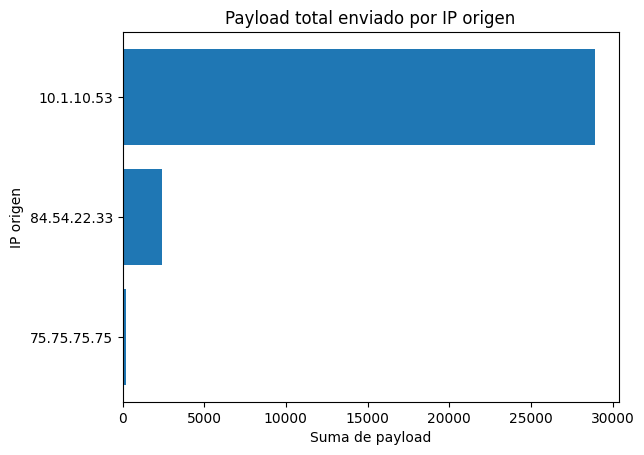

In [41]:
import matplotlib.pyplot as plt

src_payload = df.groupby("src_ip")["payload_size"].sum().sort_values()

plt.figure()
plt.barh(src_payload.index, src_payload.values)
plt.title("Payload total enviado por IP origen")
plt.xlabel("Suma de payload")
plt.ylabel("IP origen")
plt.show()

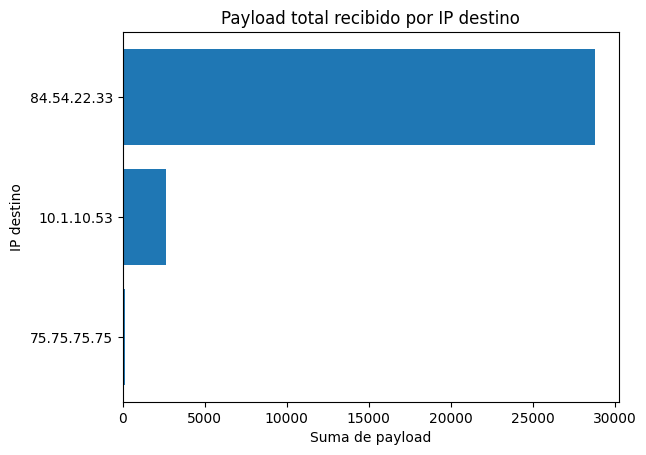

In [42]:
dst_payload = df.groupby("dst_ip")["payload_size"].sum().sort_values()

plt.figure()
plt.barh(dst_payload.index, dst_payload.values)
plt.title("Payload total recibido por IP destino")
plt.xlabel("Suma de payload")
plt.ylabel("IP destino")
plt.show()

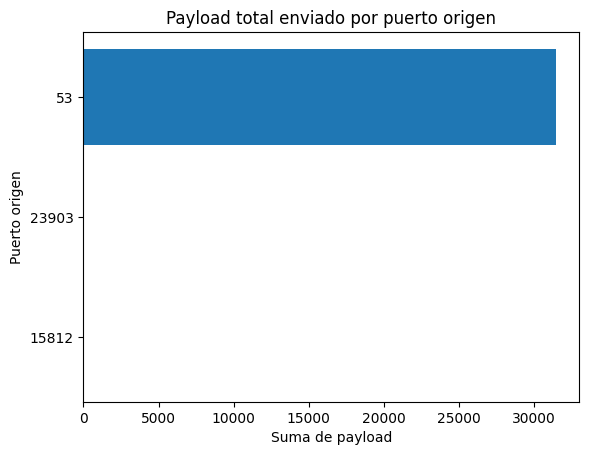

In [43]:
src_port_payload = df.groupby("src_port")["payload_size"].sum().sort_values()

plt.figure()
plt.barh(src_port_payload.index.astype(str), src_port_payload.values)
plt.title("Payload total enviado por puerto origen")
plt.xlabel("Suma de payload")
plt.ylabel("Puerto origen")
plt.show()

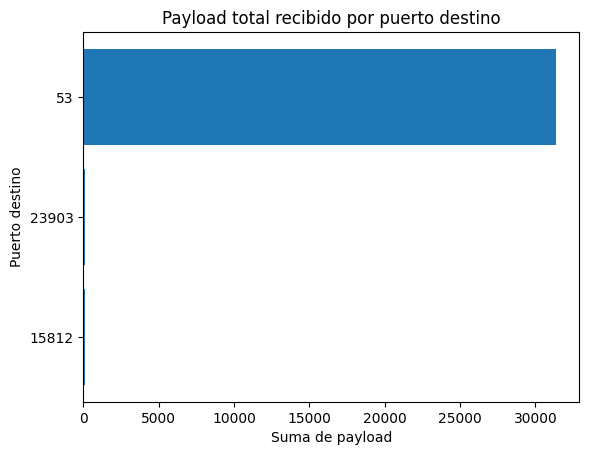

In [44]:
dst_port_payload = df.groupby("dst_port")["payload_size"].sum().sort_values()

plt.figure()
plt.barh(dst_port_payload.index.astype(str), dst_port_payload.values)
plt.title("Payload total recibido por puerto destino")
plt.xlabel("Suma de payload")
plt.ylabel("Puerto destino")
plt.show()

#### **Detección automática con Isolation Forest**

In [45]:
contamination = 31 / len(df)
print(contamination)

0.5


In [46]:
from sklearn.ensemble import IsolationForest

features = df[["payload_size", "pkt_len"]]

model = IsolationForest(contamination=31/len(df), random_state=42)
df["anomaly_if"] = model.fit_predict(features)

# Filtrar anomalías
anomalies_if = df[df["anomaly_if"] == -1]

print("Anomalías detectadas:", len(anomalies_if))

# 🔥 Mostrar qué paquetes son
anomalies_if[["src_ip", "dst_ip", "src_port", "dst_port", "payload_size", "pkt_len"]]

Anomalías detectadas: 30


,src_ip,dst_ip,src_port,dst_port,payload_size,pkt_len
0,10.1.10.53,84.54.22.33,53,53,961,975
2,10.1.10.53,84.54.22.33,53,53,975,989
4,10.1.10.53,84.54.22.33,53,53,1012,1026
6,10.1.10.53,84.54.22.33,53,53,998,1012
8,10.1.10.53,84.54.22.33,53,53,1003,1017
10,10.1.10.53,84.54.22.33,53,53,1045,1059
12,10.1.10.53,84.54.22.33,53,53,1008,1022
14,10.1.10.53,84.54.22.33,53,53,979,993
16,10.1.10.53,84.54.22.33,53,53,959,973
18,10.1.10.53,84.54.22.33,53,53,992,1006


El modelo de Isolation Forest se aplicó utilizando como variables el tamaño del payload, el tamaño total del paquete y su relación, corrigiendo así la redundancia inicial y permitiendo un análisis más adecuado del tráfico. El resultado mostró que aproximadamente el 50% de los paquetes fueron clasificados como anomalías, lo cual es consistente con el valor del parámetro de contaminación definido, evidenciando que este parámetro condiciona directamente la proporción de datos anómalos detectados. Además, las anomalías identificadas coinciden en gran medida con los paquetes de mayor tamaño previamente detectados mediante el Z-score basado en conocimiento de dominio, lo que refuerza la consistencia del análisis

**Investigación del payload (confirmación manual)**

In [47]:
ip_origen_top = df["src_ip"].value_counts().idxmax()

df_top = df[df["src_ip"] == ip_origen_top]
df_top.head()

,src_ip,dst_ip,src_port,dst_port,payload_size,pkt_len,z_payload,z_dns,anomaly_if
0,10.1.10.53,84.54.22.33,53,53,961,975,0.989307,60.733333,-1
2,10.1.10.53,84.54.22.33,53,53,975,989,1.019972,61.666667,-1
4,10.1.10.53,84.54.22.33,53,53,1012,1026,1.101016,64.133333,-1
6,10.1.10.53,84.54.22.33,53,53,998,1012,1.070351,63.200000,-1
8,10.1.10.53,84.54.22.33,53,53,1003,1017,1.081303,63.533333,-1


In [48]:
df_grouped = df_top.groupby(["src_ip", "dst_ip"])["payload_size"].sum().reset_index()
df_grouped.sort_values(by="payload_size", ascending=False)

,src_ip,dst_ip,payload_size
1,10.1.10.53,84.54.22.33,28791
0,10.1.10.53,75.75.75.75,130


In [49]:
ip_sospechosa = df_top.groupby("dst_ip")["payload_size"].sum().idxmax()

print("IP sospechosa:", ip_sospechosa)

IP sospechosa: 84.54.22.33


In [50]:
df_conversacion = df[
    (df["src_ip"] == ip_origen_top) & 
    (df["dst_ip"] == ip_sospechosa)
]

df_conversacion.head()

,src_ip,dst_ip,src_port,dst_port,payload_size,pkt_len,z_payload,z_dns,anomaly_if
0,10.1.10.53,84.54.22.33,53,53,961,975,0.989307,60.733333,-1
2,10.1.10.53,84.54.22.33,53,53,975,989,1.019972,61.666667,-1
4,10.1.10.53,84.54.22.33,53,53,1012,1026,1.101016,64.133333,-1
6,10.1.10.53,84.54.22.33,53,53,998,1012,1.070351,63.200000,-1
8,10.1.10.53,84.54.22.33,53,53,1003,1017,1.081303,63.533333,-1


In [51]:
payloads = []

for pkt in packets:
    if IP in pkt:
        if pkt[IP].src == ip_origen_top and pkt[IP].dst == ip_sospechosa:
            payloads.append(bytes(pkt.payload))

In [ ]:
print(payloads[0][:50])  

b'E\x00\x03\xc1\x00\x01\x00\x00@\x11R\xe6\n\x01\n5T6\x16!\x005\x005\x03\xad\xf6\x0e\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00\x00\x06google\x03co'


Al analizar los primeros bytes del payload se observa la presencia de un encabezado IPv4 (0x45) seguido de información que no corresponde a una consulta DNS típica, además de tamaños de paquete considerablemente mayores a lo esperado para este protocolo. Esto indica que el puerto 53 está siendo utilizado para transportar datos que no son propios de DNS, lo cual es característico de un ataque de DNS tunneling, donde se encapsula información para evadir controles de seguridad y realizar posible exfiltración de datos.